SHAP values for modelling 3 CatBoost models

# Import libraries

In [2]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter(action='ignore', category=NumbaDeprecationWarning)

In [8]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(
    str(Path('..', 'utils_functionality', 'split_utils'))
)
sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling3_utils import (
    # _prepare_df,
    MLPipeline,
    _create_pipeline,
    StatsModelsEstimator,
)
from catboost import CatBoostClassifier

# Splashing

In [3]:
pipeline_spl = joblib.load('../results/models_modelling3/CatBoostClassifier_splashing_base')
cb_model = pipeline_spl.steps[3][1]

In [4]:
ml_pipe = MLPipeline(
    target='splashing',
    estimator=cb_model,
    features_to_drop = (
        'Re', 
        'We', 
        'init_volume_fraction',
        'particle_droplet_diameter_ratio', 
        'sedimentation_Re',
        # 'particle_liquid_density_ratio',
        'sedimentation_Stk'
        # 'sign_sedimentation_Re',
        # 'volume_fraction', 
        # 'relative_roughness', 
        # 'inclination',
        # 'wettability',
    ),
    model_postfix='test',)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


None

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sign_sedimentation_Re',
                                  'particle_liquid_density_ratio',
                                  'relative_roughness', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

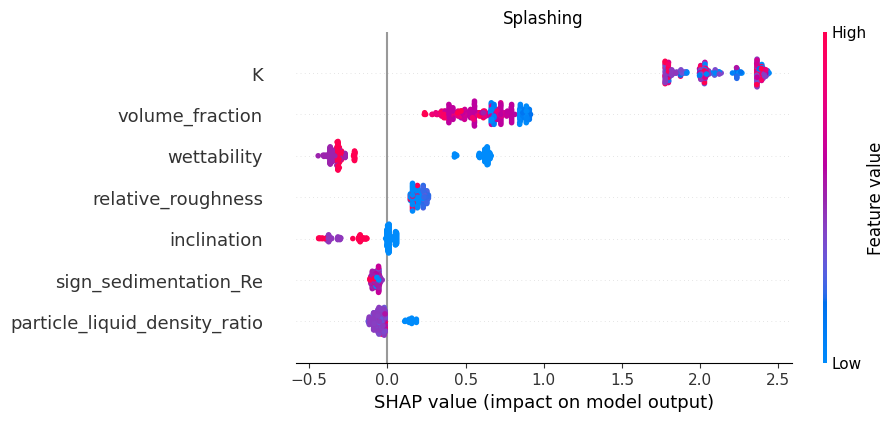

In [5]:
X = ml_pipe.train[cb_model.feature_names_]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values, show=False)
plt.title('Splashing')
plt.show()

# No fragmentation

In [6]:
pipeline_spl = joblib.load('../results/models_modelling3/CatBoostClassifier_no_fragmentation_base')
cb_model = pipeline_spl.steps[3][1]

In [7]:
ml_pipe = MLPipeline(
    target='no_fragmentation',
    estimator=cb_model,
    features_to_drop = (
        'Re', 
        'We', 
        'init_volume_fraction',
        'particle_droplet_diameter_ratio', 
        'sedimentation_Re',
        # 'particle_liquid_density_ratio',
        'sedimentation_Stk'
        # 'sign_sedimentation_Re',
        # 'volume_fraction', 
        # 'relative_roughness', 
        # 'inclination',
        # 'wettability',
    ),
    model_postfix='test',)

Load dataset from: ../data/df_dimless.xlsx
Keep "no_fragmentation" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_no_fragmentation.xlsx
std_features


None

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sign_sedimentation_Re',
                                  'particle_liquid_density_ratio',
                                  'relative_roughness', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

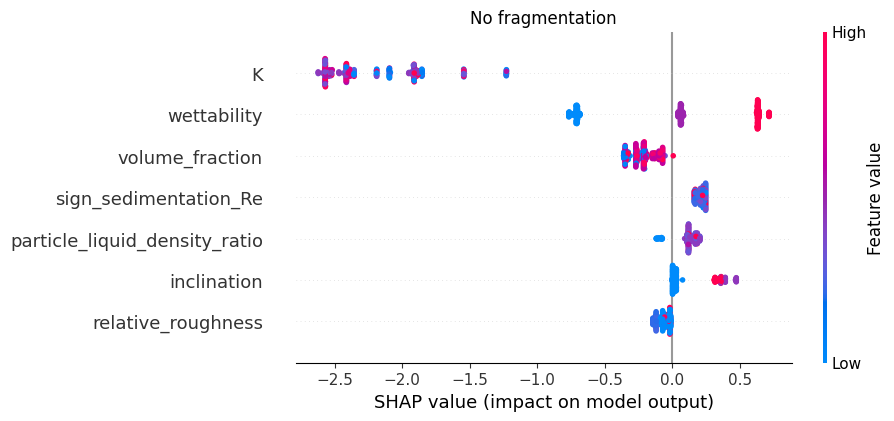

In [8]:
X = ml_pipe.train[cb_model.feature_names_]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values, show=False)
plt.title('No fragmentation')
plt.show()

# All features

## Splashing

In [4]:
ml_pipe = MLPipeline(
    target='splashing',
    estimator=CatBoostClassifier(verbose=False),
    features_to_drop = (
    ),
    model_postfix='test',)
ml_pipe.run(save_model_and_metrics=False)

Load dataset from: ..\data\df_dimless.xlsx
Keep "splashing" from {'no_fragmentation', 'splashing'}
Load split indexes from: ..\data\df_ml_split_splashing.xlsx
std_features


('init_volume_fraction',
 'sedimentation_Re',
 'sign_sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('init_volume_fraction', 'sedimentation_Re',
                                  'sign_sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. 

no summary in estimator class "CatBoostClassifier"


iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.


,0
target,splashing
model,CatBoostClassifier_splashing_test
holdout_test_accuracy,0.866667
holdout_test_f1,0.901961
holdout_test_roc_auc,0.95216
cv_test_accuracy_median,0.90566
cv_test_f1_median,0.925373
cv_test_roc_auc_median,0.95873


In [6]:
cb_model = ml_pipe.pipe.steps[3][1]

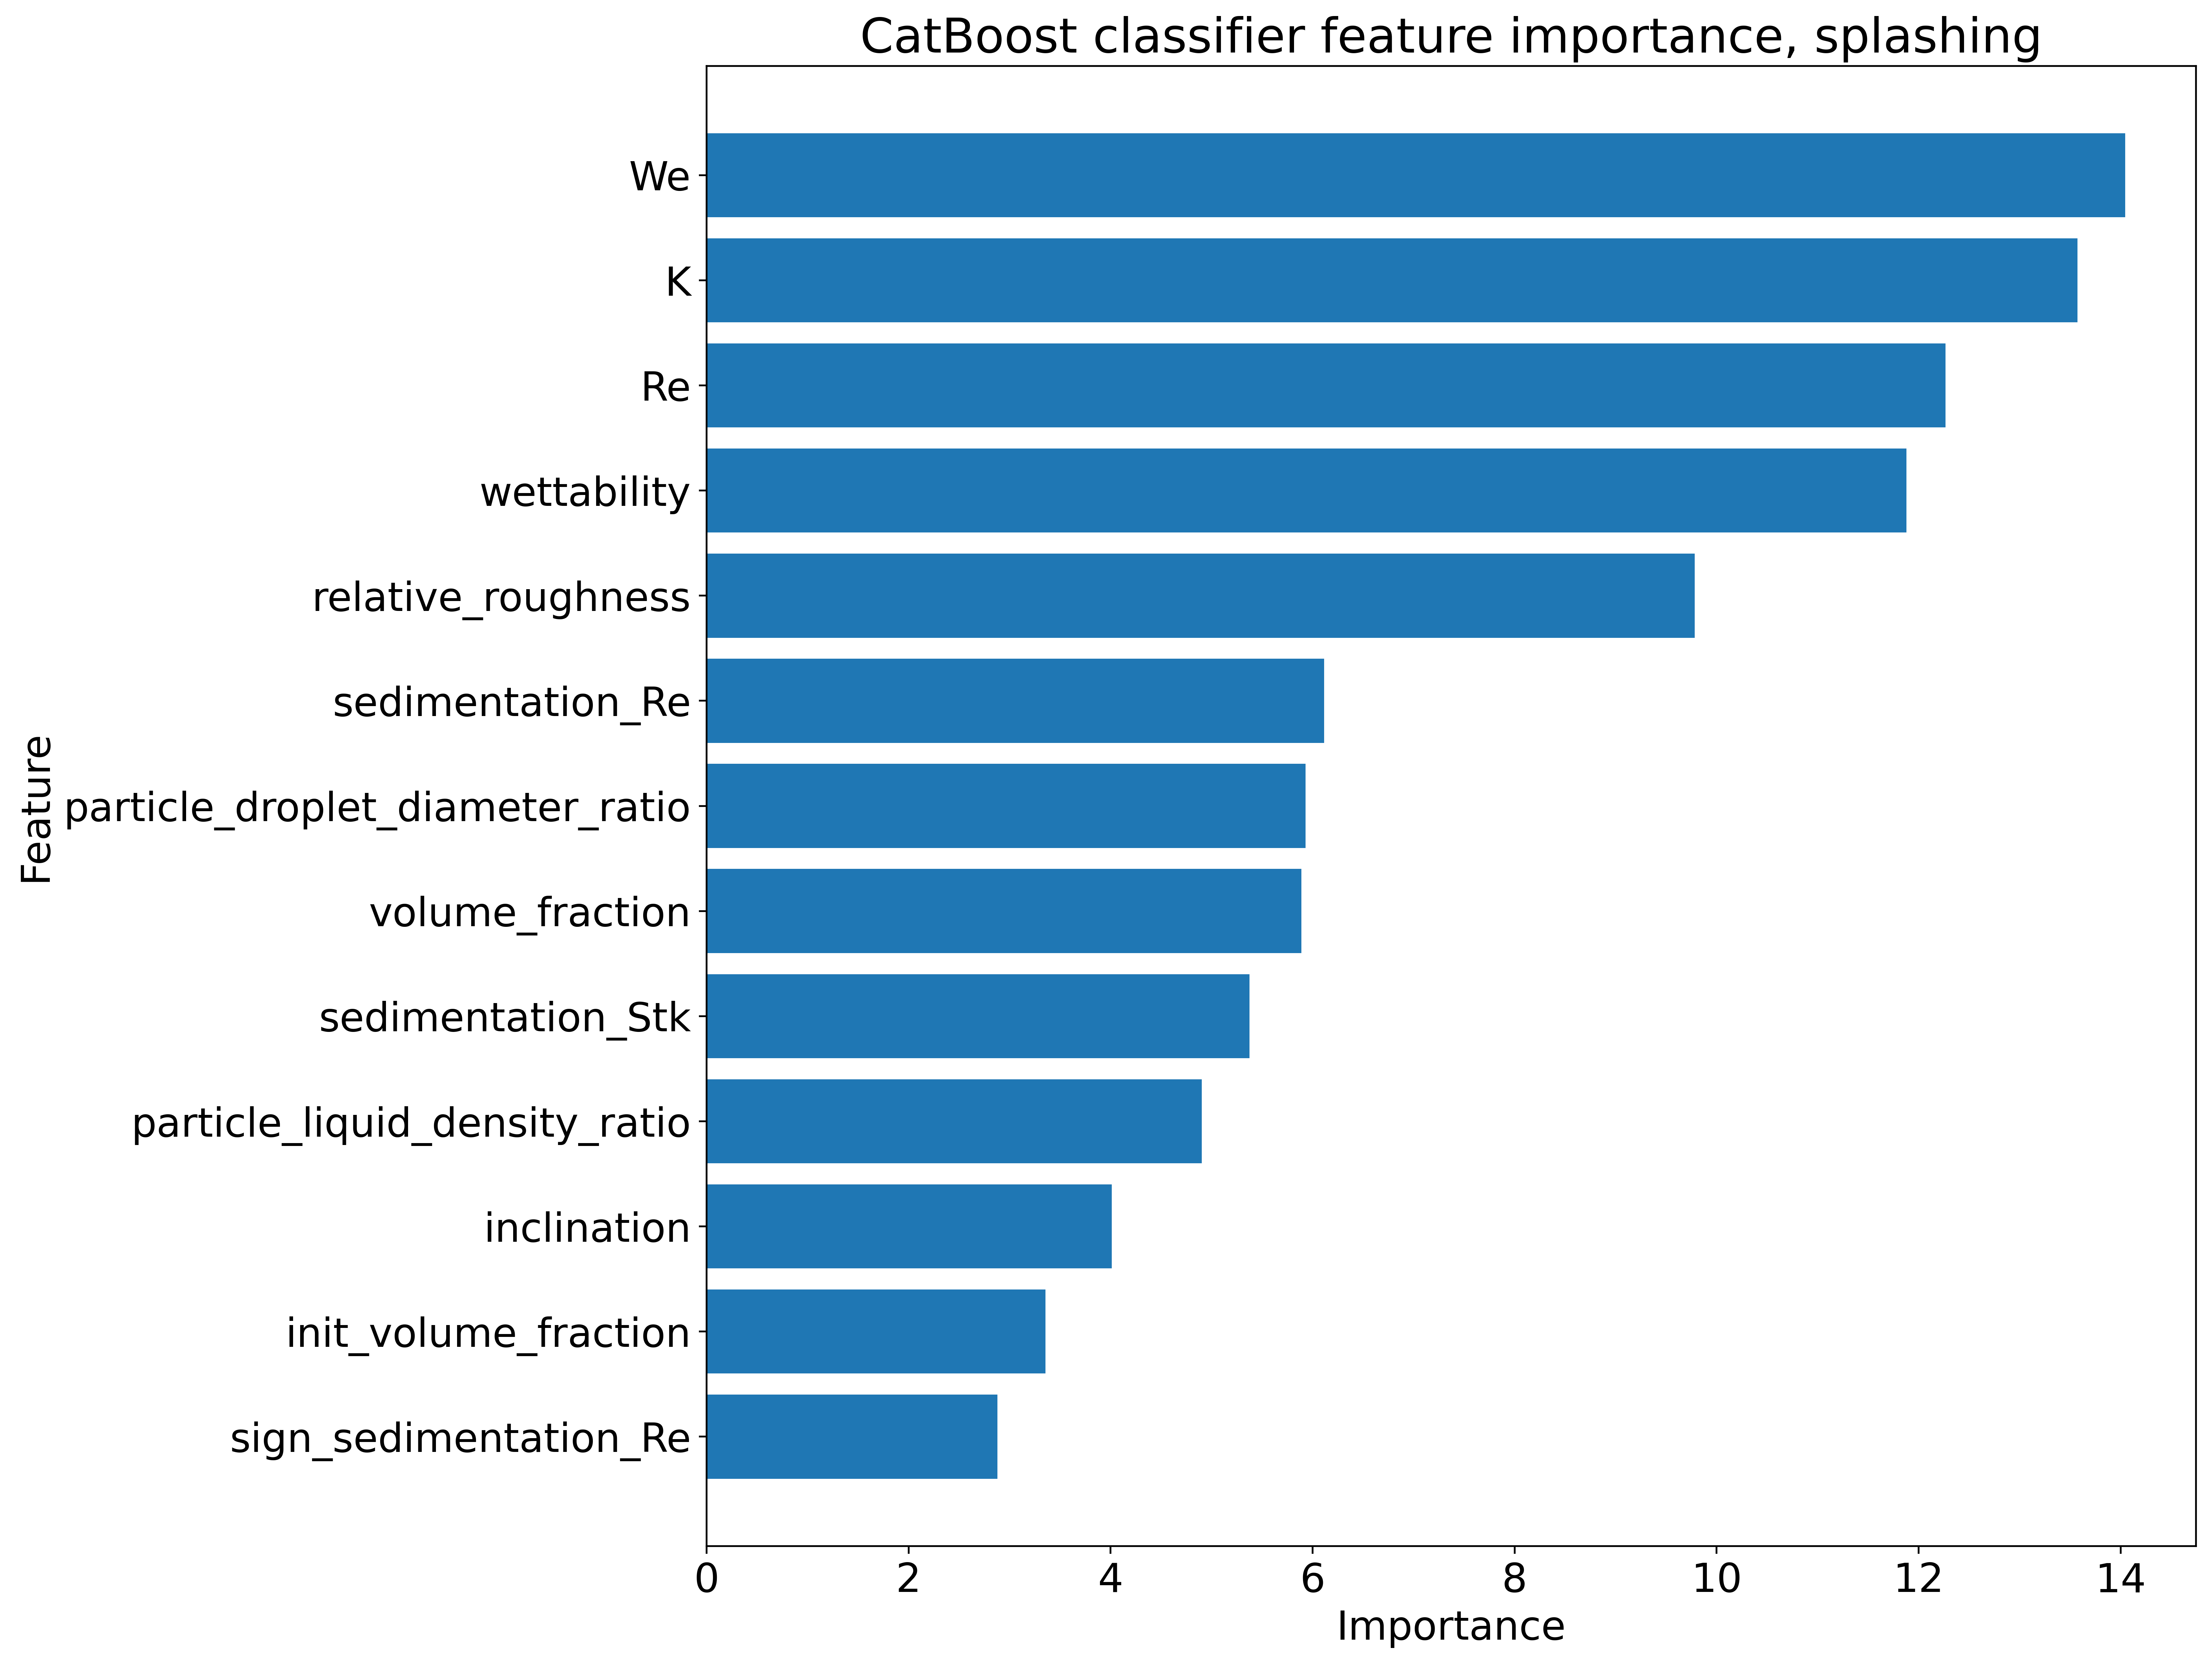

In [9]:
importances = cb_model.feature_importances_
feature_names = cb_model.feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('CatBoost classifier feature importance, splashing')
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


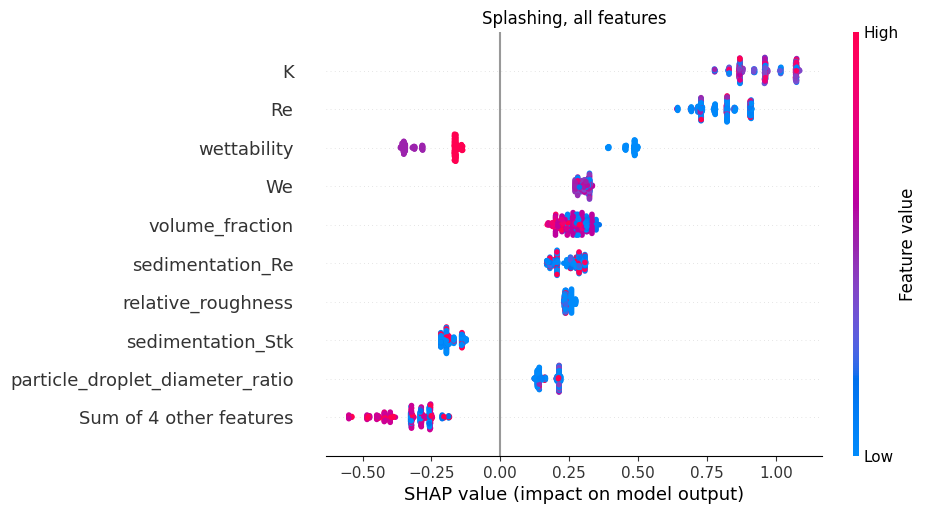

In [21]:
cb_model = ml_pipe.pipe.steps[3][1]
X = ml_pipe.train[cb_model.feature_names_]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values, show=False)
plt.title('Splashing, all features')
plt.show()

## No fragmentation

In [10]:
ml_pipe = MLPipeline(
    target='no_fragmentation',
    estimator=CatBoostClassifier(verbose=False),
    features_to_drop = (
    ),
    model_postfix='test',)
ml_pipe.run(save_model_and_metrics=False)

Load dataset from: ..\data\df_dimless.xlsx
Keep "no_fragmentation" from {'no_fragmentation', 'splashing'}
Load split indexes from: ..\data\df_ml_split_no_fragmentation.xlsx
std_features


('init_volume_fraction',
 'sedimentation_Re',
 'sign_sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('init_volume_fraction', 'sedimentation_Re',
                                  'sign_sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. 

no summary in estimator class "CatBoostClassifier"


iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.
iteritems is deprecated and will be removed in a future version. Use .items instead.


,0
target,no_fragmentation
model,CatBoostClassifier_no_fragmentation_test
holdout_test_accuracy,0.933333
holdout_test_f1,0.878049
holdout_test_roc_auc,0.981818
cv_test_accuracy_median,0.924528
cv_test_f1_median,0.846154
cv_test_roc_auc_median,0.976068


In [11]:
cb_model = ml_pipe.pipe.steps[3][1]

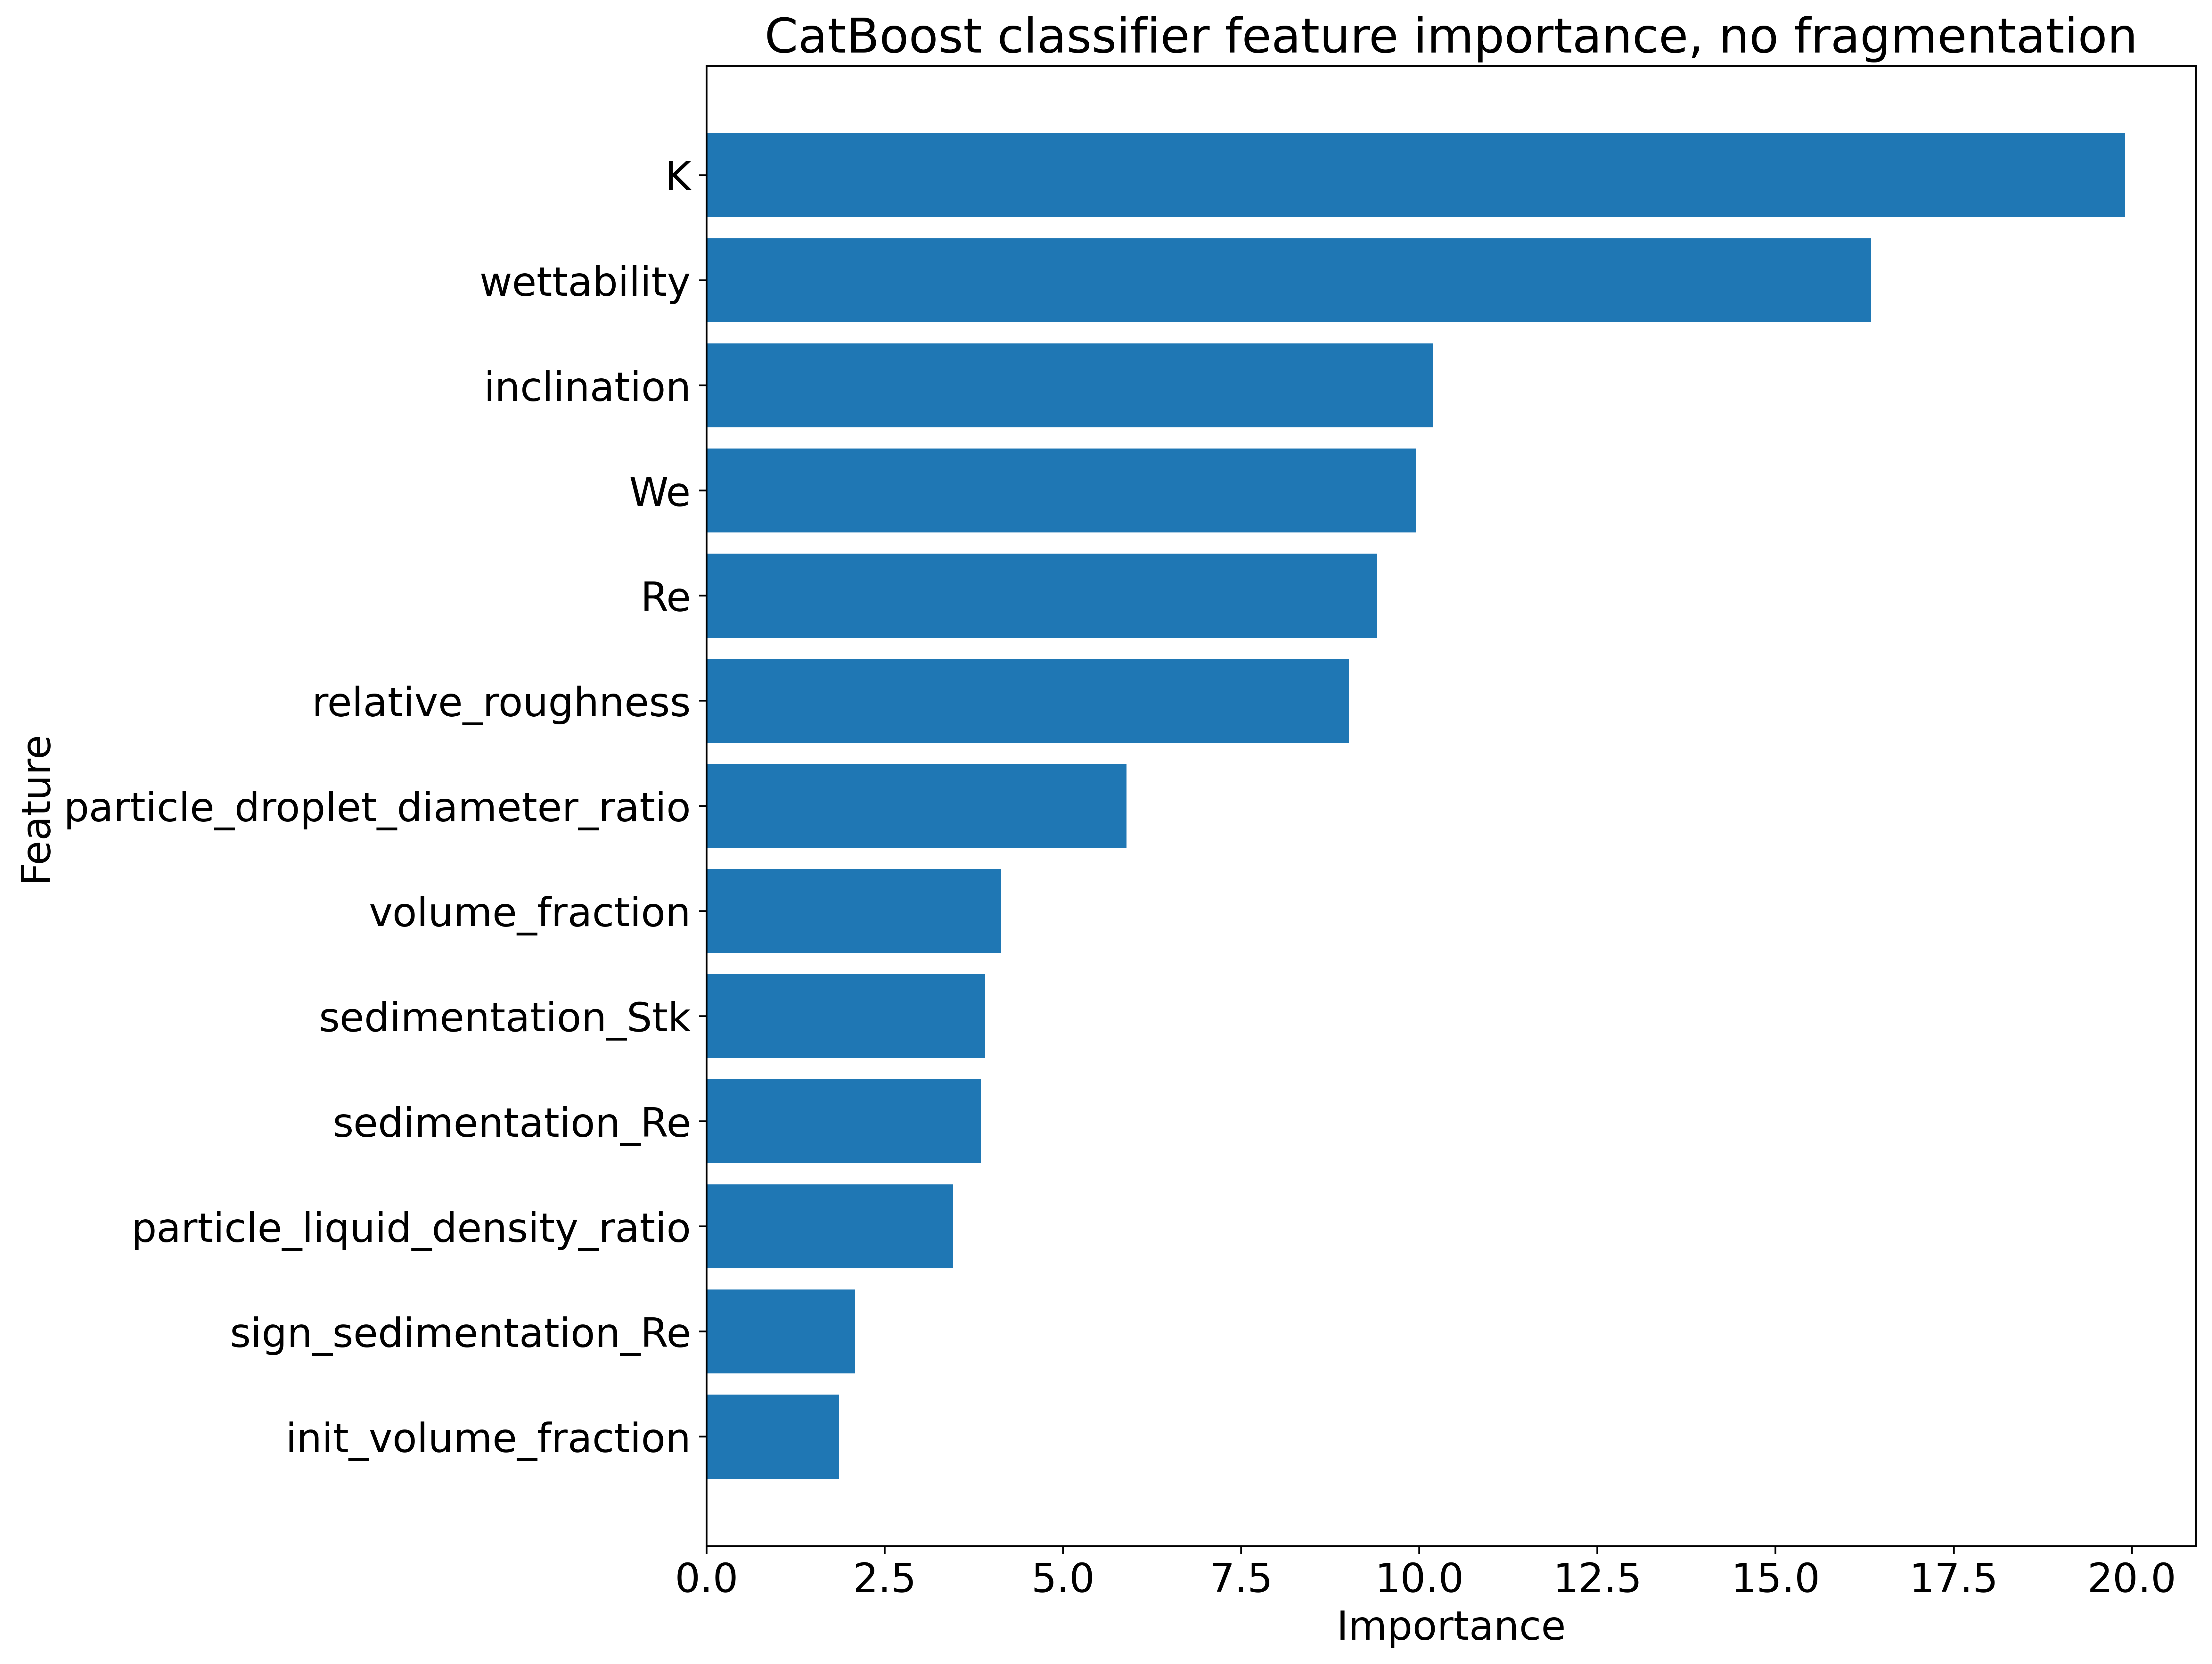

In [12]:
importances = cb_model.feature_importances_
feature_names = cb_model.feature_names_

df_permut_feature_importance = pd.DataFrame(
    {'Feature name': feature_names, 
     'Feature importance': importances}
).sort_values(by='Feature importance')

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(12, 12),dpi=500)
plt.barh(
    y=df_permut_feature_importance['Feature name'],
    width=df_permut_feature_importance['Feature importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('CatBoost classifier feature importance, no fragmentation')
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


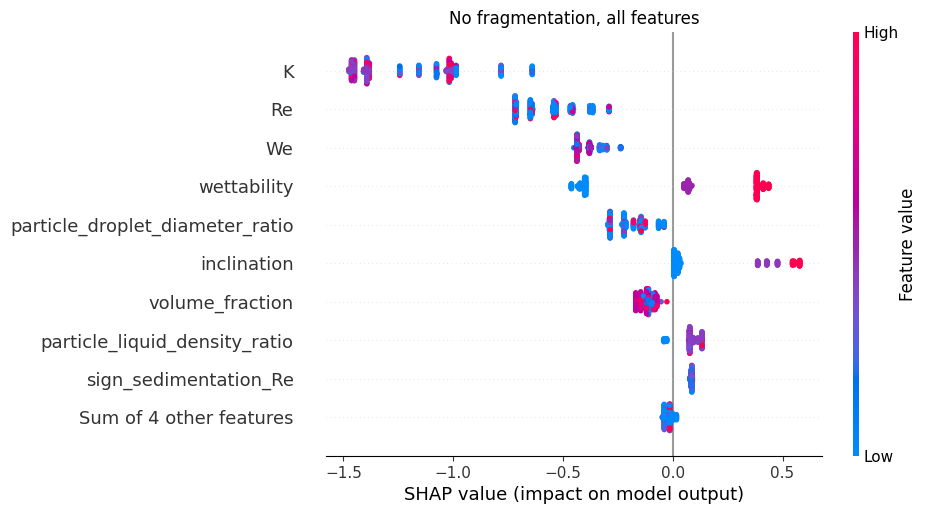

In [23]:
X = ml_pipe.train[cb_model.feature_names_]
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(X)
shap.plots.beeswarm(shap_values, show=False)
plt.title('No fragmentation, all features')
plt.show()